In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
print("Libraries imported")

Libraries imported


In [2]:
timeseries = pd.read_csv(
    "../data/hf_dataset/sepsis_timeseries_hourly.csv"
)
cohort = pd.read_csv(
    "../data/hf_dataset/sepsis_cohort.csv"
)
print("Timeseries shape:", timeseries.shape)
print("Cohort shape:", cohort.shape)  ### cohort specific grp of patient


Timeseries shape: (851717, 64)
Cohort shape: (32971, 12)


In [3]:
timeseries["starttime"] = pd.to_datetime(timeseries["starttime"])
timeseries["endtime"] = pd.to_datetime(timeseries["endtime"])
cohort["sepsis_time"] = pd.to_datetime(cohort["sepsis_time"])
cohort["icu_intime"] = pd.to_datetime(cohort["icu_intime"])
cohort["icu_outtime"] = pd.to_datetime(cohort["icu_outtime"])

print("Datetime conversion complete")

Datetime conversion complete


In [4]:
model = timeseries.merge(
    cohort[["stay_id", "sepsis_time"]],
    on="stay_id",
    how="left"
)

model["hours_from_sepsis"] = (
    model["starttime"] - model["sepsis_time"]
).dt.total_seconds() / 3600

model[
    [
        "stay_id",
        "starttime",
        "sepsis_time",
        "hours_from_sepsis",
        "sofa_score"
    ]
].head(15)

,stay_id,starttime,sepsis_time,hours_from_sepsis,sofa_score
0,30000484,2136-01-14 17:23:32,2136-01-14 19:00:00,-1.607778,NaN
1,30000484,2136-01-14 18:23:32,2136-01-14 19:00:00,-0.607778,3.0
2,30000484,2136-01-14 19:23:32,2136-01-14 19:00:00,0.392222,1.0
3,30000484,2136-01-14 20:23:32,2136-01-14 19:00:00,1.392222,1.0
4,30000484,2136-01-14 21:23:32,2136-01-14 19:00:00,2.392222,0.0
5,30000484,2136-01-14 22:23:32,2136-01-14 19:00:00,3.392222,1.0
6,30000484,2136-01-14 23:23:32,2136-01-14 19:00:00,4.392222,1.0
7,30000484,2136-01-15 00:23:32,2136-01-14 19:00:00,5.392222,2.0
8,30000484,2136-01-15 01:23:32,2136-01-14 19:00:00,6.392222,1.0
9,30000484,2136-01-15 02:23:32,2136-01-14 19:00:00,7.392222,1.0


In [5]:
post_sepsis = model[
    model["hours_from_sepsis"] >= 0
].copy()

print("Post-sepsis observations:", len(post_sepsis))
print("Post-sepsis ICU stays:", post_sepsis["stay_id"].nunique())

Post-sepsis observations: 605121
Post-sepsis ICU stays: 31333


In [6]:
### to checkkk or predict deteriattion at 6hr 12hr .....
duration = (
    post_sepsis
    .groupby("stay_id")["hours_from_sepsis"]
    .max()

)
print(duration.describe(
    percentiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
))

count    31333.000000
mean        18.809560
std          4.562092
min          0.000000
10%         12.192444
25%         17.383333
50%         20.501944
75%         22.000000
90%         22.483333
95%         22.686944
99%         22.954178
max         40.856111
Name: hours_from_sepsis, dtype: float64


In [7]:
post_sepsis = post_sepsis.sort_values(
    ["stay_id", "starttime"]
)

time_gap = (
    post_sepsis
    .groupby("stay_id")["starttime"]
    .diff()
    .dt.total_seconds() / 3600
)
print(time_gap.describe())

print(
    "Gaps greater than 1.5 hours:",
    (time_gap > 1.5).sum()
)

count    573788.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: starttime, dtype: float64
Gaps greater than 1.5 hours: 0


In [8]:
post_sepsis[
    [
        "stay_id",
        "starttime",
        "hours_from_sepsis",
        "sofa_score",
        "sofa_24hours"
    ]
].head(20)

,stay_id,starttime,hours_from_sepsis,sofa_score,sofa_24hours
2,30000484,2136-01-14 19:23:32,0.392222,1.0,4
3,30000484,2136-01-14 20:23:32,1.392222,1.0,4
4,30000484,2136-01-14 21:23:32,2.392222,0.0,4
5,30000484,2136-01-14 22:23:32,3.392222,1.0,4
6,30000484,2136-01-14 23:23:32,4.392222,1.0,4
7,30000484,2136-01-15 00:23:32,5.392222,2.0,4
8,30000484,2136-01-15 01:23:32,6.392222,1.0,4
9,30000484,2136-01-15 02:23:32,7.392222,1.0,4
10,30000484,2136-01-15 03:23:32,8.392222,1.0,4
11,30000484,2136-01-15 04:23:32,9.392222,4.0,5


In [9]:
### sofa for 1 - 6 hrs
post_sepsis["sofa_t_plus_1"] = (
    post_sepsis.groupby("stay_id")["sofa_score"].shift(-1)
)

post_sepsis["sofa_t_plus_2"] = (
    post_sepsis.groupby("stay_id")["sofa_score"].shift(-2)
)

post_sepsis["sofa_t_plus_3"] = (
    post_sepsis.groupby("stay_id")["sofa_score"].shift(-3)
)

post_sepsis["sofa_t_plus_4"] = (
    post_sepsis.groupby("stay_id")["sofa_score"].shift(-4)
)

post_sepsis["sofa_t_plus_5"] = (
    post_sepsis.groupby("stay_id")["sofa_score"].shift(-5)
)

post_sepsis["sofa_t_plus_6"] = (
    post_sepsis.groupby("stay_id")["sofa_score"].shift(-6)
)

In [10]:
post_sepsis[
    [
        "stay_id",
        "hours_from_sepsis",
        "sofa_score",
        "sofa_t_plus_1",
        "sofa_t_plus_2",
        "sofa_t_plus_3",
        "sofa_t_plus_4",
        "sofa_t_plus_5",
        "sofa_t_plus_6"
    ]
].head(20)   ### a patient's sofa score at diff time

,stay_id,hours_from_sepsis,sofa_score,sofa_t_plus_1,sofa_t_plus_2,sofa_t_plus_3,sofa_t_plus_4,sofa_t_plus_5,sofa_t_plus_6
2,30000484,0.392222,1.0,1.0,0.0,1.0,1.0,2.0,1.0
3,30000484,1.392222,1.0,0.0,1.0,1.0,2.0,1.0,1.0
4,30000484,2.392222,0.0,1.0,1.0,2.0,1.0,1.0,1.0
5,30000484,3.392222,1.0,1.0,2.0,1.0,1.0,1.0,4.0
6,30000484,4.392222,1.0,2.0,1.0,1.0,1.0,4.0,1.0
7,30000484,5.392222,2.0,1.0,1.0,1.0,4.0,1.0,2.0
8,30000484,6.392222,1.0,1.0,1.0,4.0,1.0,2.0,6.0
9,30000484,7.392222,1.0,1.0,4.0,1.0,2.0,6.0,1.0
10,30000484,8.392222,1.0,4.0,1.0,2.0,6.0,1.0,3.0
11,30000484,9.392222,4.0,1.0,2.0,6.0,1.0,3.0,3.0


In [11]:
#Did the patient's SOFA increase at any point during the next 6 hours
future_sofa_columns = [
    "sofa_t_plus_1",
    "sofa_t_plus_2",
    "sofa_t_plus_3",
    "sofa_t_plus_4",
    "sofa_t_plus_5",
    "sofa_t_plus_6"
]

post_sepsis["future_max_sofa_6h"] = (
    post_sepsis[future_sofa_columns]
    .max(axis=1, skipna=True)
)

In [12]:
post_sepsis["delta_sofa_6h"] = (
    post_sepsis["future_max_sofa_6h"]
    - post_sepsis["sofa_score"]
)

count    552026.000000
mean          1.151694
std           2.042372
min         -17.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          17.000000
Name: delta_sofa_6h, dtype: float64


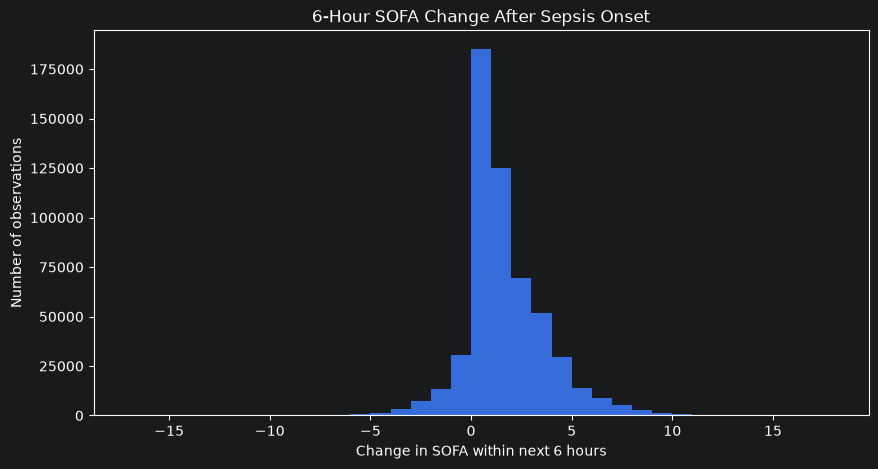

In [13]:
valid = post_sepsis[
    post_sepsis["sofa_score"].notna()  ## notona fn to check to non missingn value
    & post_sepsis["future_max_sofa_6h"].notna()
].copy()

print(valid["delta_sofa_6h"].describe())
plt.figure(figsize=(10, 5))

plt.hist(
    valid["delta_sofa_6h"],
    bins=range(
        int(valid["delta_sofa_6h"].min()),
        int(valid["delta_sofa_6h"].max()) + 2
    )
)

plt.xlabel("Change in SOFA within next 6 hours")
plt.ylabel("Number of observations")
plt.title("6-Hour SOFA Change After Sepsis Onset")

plt.show() ### graph negative shows the patient is improving and more the ppositive sofa means patient is deterioting

In [14]:
for threshold in [1, 2, 3]:

    deterioration = (
        valid["delta_sofa_6h"] >= threshold
    )

    print(
        f"SOFA increase >= {threshold}:",
        deterioration.sum(),
        f"({deterioration.mean()*100:.2f}%)"
    )

SOFA increase >= 1: 309423 (56.05%)
SOFA increase >= 2: 184425 (33.41%)
SOFA increase >= 3: 114736 (20.78%)


In [16]:
import pandas as pd

model = pd.read_csv("../data/processed/model_a_features.csv")

print(model.shape)
print(model.columns.tolist())

(851717, 91)
['stay_id', 'hour', 'heart_rate', 'resp_rate', 'temperature', 'sbp', 'dbp', 'mbp', 'spo2', 'gcs', 'creatinine', 'bun', 'urineoutput_last', 'urineoutput_sum', 'urineoutput_24hr', 'wbc', 'hemoglobin', 'hematocrit', 'platelet', 'bands', 'sodium', 'potassium', 'chloride', 'bicarbonate', 'calcium', 'magnesium', 'aniongap', 'albumin', 'bilirubin_total', 'bilirubin_max', 'inr', 'pt', 'ptt', 'crp', 'lactate', 'pao2fio2ratio_novent', 'pao2fio2ratio_vent', 'glucose_lab', 'shock_index', 'map_calculated', 'bun_creatinine_ratio', 'spo2_deficit', 'heart_rate_prev', 'heart_rate_delta', 'resp_rate_prev', 'resp_rate_delta', 'temperature_prev', 'temperature_delta', 'sbp_prev', 'sbp_delta', 'mbp_prev', 'mbp_delta', 'spo2_prev', 'spo2_delta', 'gcs_prev', 'gcs_delta', 'heart_rate_roll3_mean', 'heart_rate_roll3_std', 'heart_rate_roll3_max', 'heart_rate_roll3_min', 'heart_rate_roll6_mean', 'resp_rate_roll3_mean', 'resp_rate_roll6_mean', 'resp_rate_roll3_std', 'resp_rate_roll3_max', 'resp_rate_ro

In [17]:
print("delta_sofa_6h" in model.columns)

False


In [18]:
sofa = pd.read_csv("../data/hf_dataset/sepsis_sofa_hourly_clock.csv")

print(sofa.shape)
print(sofa.columns.tolist())
sofa.head()

(812621, 29)
['stay_id', 'hr', 'starttime', 'endtime', 'pao2fio2ratio_novent', 'pao2fio2ratio_vent', 'rate_epinephrine', 'rate_norepinephrine', 'rate_dopamine', 'rate_dobutamine', 'meanbp_min', 'gcs_min', 'uo_24hr', 'bilirubin_max', 'creatinine_max', 'platelet_min', 'respiration', 'coagulation', 'liver', 'cardiovascular', 'cns', 'renal', 'respiration_24hours', 'coagulation_24hours', 'liver_24hours', 'cardiovascular_24hours', 'cns_24hours', 'renal_24hours', 'sofa_24hours']


,stay_id,hr,starttime,endtime,pao2fio2ratio_novent,pao2fio2ratio_vent,rate_epinephrine,rate_norepinephrine,rate_dopamine,rate_dobutamine,meanbp_min,gcs_min,uo_24hr,bilirubin_max,creatinine_max,platelet_min,respiration,coagulation,liver,cardiovascular,cns,renal,respiration_24hours,coagulation_24hours,liver_24hours,cardiovascular_24hours,cns_24hours,renal_24hours,sofa_24hours
0,30000484,0,2136-01-14 18:00:00,2136-01-14 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,81.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.0,NaN,0,0,0,0,3,0,3
1,30000484,1,2136-01-14 19:00:00,2136-01-14 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,1,3,0,4
2,30000484,2,2136-01-14 20:00:00,2136-01-14 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,62.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,1,3,0,4
3,30000484,3,2136-01-14 21:00:00,2136-01-14 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0,0,0,1,3,0,4
4,30000484,4,2136-01-14 22:00:00,2136-01-14 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,1,3,0,4


In [20]:
model = timeseries.merge(
    cohort[["stay_id", "sepsis_time"]],
    on="stay_id",
    how="left"
)

model["hours_from_sepsis"] = (
    model["starttime"] - model["sepsis_time"]
).dt.total_seconds() / 3600

print("Model shape:", model.shape)
print(
    model[
        ["stay_id", "starttime", "sepsis_time", "hours_from_sepsis", "sofa_score"]
    ].head()
)

Model shape: (851717, 66)
    stay_id           starttime         sepsis_time  hours_from_sepsis  \
0  30000484 2136-01-14 17:23:32 2136-01-14 19:00:00          -1.607778   
1  30000484 2136-01-14 18:23:32 2136-01-14 19:00:00          -0.607778   
2  30000484 2136-01-14 19:23:32 2136-01-14 19:00:00           0.392222   
3  30000484 2136-01-14 20:23:32 2136-01-14 19:00:00           1.392222   
4  30000484 2136-01-14 21:23:32 2136-01-14 19:00:00           2.392222   

   sofa_score  
0         NaN  
1         3.0  
2         1.0  
3         1.0  
4         0.0  


In [21]:
post_sepsis = model[
    model["hours_from_sepsis"] >= 0
].copy()

print("Post-sepsis observations:", len(post_sepsis))
print("Post-sepsis ICU stays:", post_sepsis["stay_id"].nunique())

Post-sepsis observations: 605121
Post-sepsis ICU stays: 31333


In [22]:
duration = (
    post_sepsis
    .groupby("stay_id")["hours_from_sepsis"]
    .max()
)

print(duration.describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
))

count    31333.000000
mean        18.809560
std          4.562092
min          0.000000
10%         12.192444
25%         17.383333
50%         20.501944
75%         22.000000
90%         22.483333
95%         22.686944
99%         22.954178
max         40.856111
Name: hours_from_sepsis, dtype: float64


In [23]:
duration = (
    post_sepsis
    .groupby("stay_id")["hours_from_sepsis"]
    .max()
)

print(duration.describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
))    ### patient with sepsis and their time at hospital max 40 hrs

count    31333.000000
mean        18.809560
std          4.562092
min          0.000000
10%         12.192444
25%         17.383333
50%         20.501944
75%         22.000000
90%         22.483333
95%         22.686944
99%         22.954178
max         40.856111
Name: hours_from_sepsis, dtype: float64


In [24]:
# Check SOFA measurements after sepsis onset

print(
    post_sepsis[
        ["stay_id", "hours_from_sepsis", "sofa_score"]
    ].head(20)
)

print("\nMissing SOFA values:")
print(post_sepsis["sofa_score"].isna().sum())

print("\nAvailable SOFA values:")
print(post_sepsis["sofa_score"].notna().sum())

     stay_id  hours_from_sepsis  sofa_score
2   30000484           0.392222         1.0
3   30000484           1.392222         1.0
4   30000484           2.392222         0.0
5   30000484           3.392222         1.0
6   30000484           4.392222         1.0
7   30000484           5.392222         2.0
8   30000484           6.392222         1.0
9   30000484           7.392222         1.0
10  30000484           8.392222         1.0
11  30000484           9.392222         4.0
12  30000484          10.392222         1.0
13  30000484          11.392222         2.0
14  30000484          12.392222         6.0
15  30000484          13.392222         1.0
16  30000484          14.392222         3.0
17  30000484          15.392222         3.0
18  30000484          16.392222         7.0
19  30000484          17.392222         3.0
20  30000484          18.392222         3.0
21  30000484          19.392222         3.0

Missing SOFA values:
21751

Available SOFA values:
583370


In [25]:
## category creating for sofa data
sofa_data = post_sepsis[
    ["stay_id","hours_from_sepsis","sofa_score"]
].dropna(subset=["sofa_score"]).copy()  ### removing sofa score which is missing in dataset
sofa_data = sofa_data.sort_values(
    ["stay_id","hours_from_sepsis"]  ## sorting values in an arrangment
)
print("SOFA observations:", len(sofa_data))
print("ICU stays:", sofa_data["stay_id"].nunique())
print("\nSOFA range:")
print(sofa_data["sofa_score"].describe())



SOFA observations: 583370
ICU stays: 31285

SOFA range:
count    583370.000000
mean          1.468281
std           1.852888
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          18.000000
Name: sofa_score, dtype: float64


the 3 classes: improving , stable , deteriorating
this can be identified using the current - previous sofa score of patient or
like future sofa score - the current sofa score
for this the eq going to bee used is sofa change = Future SOFA − Baseline SOFA
if the sofa change is highly positive then it is deteriorating if it is small positive
range then it is stable , if it is negative then it is improving

In [26]:
## creating sofa score for 6hrs later
sofa_data["future_sofa_6h"] = (
    sofa_data
    .groupby("stay_id")["sofa_score"]
    .shift(-6) ### in the patient's hourly sofa score thr new coulumn is created with 6th hours after the current one
   ## where the shift -6 goes up by 6 cells
)

In [27]:
current = sofa_data[
    ["stay_id", "hours_from_sepsis", "sofa_score"]
].copy()

future = sofa_data[
    ["stay_id", "hours_from_sepsis", "sofa_score"]
].copy()

# Rename future measurements
future = future.rename(
    columns={
        "hours_from_sepsis": "future_hours",
        "sofa_score": "future_sofa_6h"
    }
)

# We want the SOFA measurement approximately 6 hours later
current["target_future_hour"] = (
    current["hours_from_sepsis"] + 6
)

In [28]:
## creating progression table
sofa_progression = pd.merge_asof(
    current.sort_values("target_future_hour"),
    future.sort_values("future_hours"),
    left_on="target_future_hour",
    right_on="future_hours",
    by="stay_id",
    direction="nearest",
    tolerance=1.0
)
print(sofa_progression.head())

    stay_id  hours_from_sepsis  sofa_score  target_future_hour  future_hours  \
0  35438780                0.0         4.0                 6.0           6.0   
1  33631920                0.0         0.0                 6.0           6.0   
2  39709334                0.0         1.0                 6.0           6.0   
3  32279258                0.0         1.0                 6.0           6.0   
4  38634786                0.0         1.0                 6.0           6.0   

   future_sofa_6h  
0             1.0  
1             0.0  
2             1.0  
3             0.0  
4             1.0  


In [29]:
sofa_progression["delta_sofa_6h"] = (
    sofa_progression["future_sofa_6h"]
    - sofa_progression["sofa_score"]
)

In [30]:
print(
    sofa_progression[
        [
            "stay_id",
            "hours_from_sepsis",
            "sofa_score",
            "future_hours",
            "future_sofa_6h",
            "delta_sofa_6h"
        ]
    ].head(20)
)

     stay_id  hours_from_sepsis  sofa_score  future_hours  future_sofa_6h  \
0   35438780                0.0         4.0           6.0             1.0   
1   33631920                0.0         0.0           6.0             0.0   
2   39709334                0.0         1.0           6.0             1.0   
3   32279258                0.0         1.0           6.0             0.0   
4   38634786                0.0         1.0           6.0             1.0   
5   35171466                0.0         2.0           6.0             4.0   
6   39336319                0.0         0.0           6.0             0.0   
7   30711907                0.0         0.0           6.0             0.0   
8   35281527                0.0         0.0           6.0             2.0   
9   38675535                0.0         0.0           6.0             0.0   
10  33729647                0.0         0.0           6.0             0.0   
11  33786071                0.0         0.0           6.0             2.0   

In [31]:
print(
    sofa_progression["delta_sofa_6h"]
    .value_counts()
    .sort_index()
)

delta_sofa_6h
-17.0         1
-16.0         1
-15.0         1
-14.0         3
-13.0        17
-12.0        23
-11.0        80
-10.0       108
-9.0        218
-8.0        535
-7.0        927
-6.0       1755
-5.0       3127
-4.0       8001
-3.0      18821
-2.0      23480
-1.0      64121
 0.0     208798
 1.0      55558
 2.0      17579
 3.0      13463
 4.0       6378
 5.0       2430
 6.0       1599
 7.0        918
 8.0        505
 9.0        220
 10.0       151
 11.0        80
 12.0        30
 13.0        14
 14.0         6
Name: count, dtype: int64


In [33]:
## representation of the values of sofa score ahead in 6 hrs
#| SOFA change | Meaning       |   Count | Approx. |
#| ----------- | ------------- | ------: | ------: |
#| `< 0`       | Improving     | 121,218 |   28.3% |
#| `= 0`       | Stable        | 208,798 |   48.7% |
#| `> 0`       | Deteriorating |  98,931 |   23.1% |


In [32]:
def classify_progression(delta):
    if delta < 0:
        return 0       # Improving
    elif delta == 0:
        return 1       # Stable
    else:
        return 2       # Deteriorating


sofa_progression["progression_class"] = (
    sofa_progression["delta_sofa_6h"]
    .apply(classify_progression)
)

In [33]:
print(
    sofa_progression[
        ["delta_sofa_6h", "progression_class"]
    ].head(20)
)


    delta_sofa_6h  progression_class
0            -3.0                  0
1             0.0                  1
2             0.0                  1
3            -1.0                  0
4             0.0                  1
5             2.0                  2
6             0.0                  1
7             0.0                  1
8             2.0                  2
9             0.0                  1
10            0.0                  1
11            2.0                  2
12            0.0                  1
13            0.0                  1
14            2.0                  2
15            0.0                  1
16            0.0                  1
17           -5.0                  0
18            2.0                  2
19            3.0                  2


In [34]:
print(
    sofa_progression["progression_class"]
    .value_counts()
    .sort_index()
)

progression_class
0    121219
1    208798
2    253353
Name: count, dtype: int64


In [ ]:
### actual deteriorating was 92k but  now shown as 253k
###progression_class is apparently being assigned to rows where delta_sofa_6h
# may not be valid/available in the same way

In [35]:
print(
    sofa_progression.groupby("progression_class")["delta_sofa_6h"]
    .agg(["count", "min", "max"])   ## agg = aggregate means to combine multiple individual data points into a single summary value or statistic
)
print(
    sofa_progression["delta_sofa_6h"].isna().sum()   # check every row if there is missing value
)

                    count   min   max
progression_class                    
0                  121219 -17.0  -1.0
1                  208798   0.0   0.0
2                   98931   1.0  14.0
154422


### 154422 is the missing values

In [36]:
sofa_target = sofa_progression[
    sofa_progression["delta_sofa_6h"].notna()
].copy()

print("Total valid target rows:", len(sofa_target))
print("Missing targets:", sofa_target["delta_sofa_6h"].isna().sum())

print("\nClass distribution:")
print(
    sofa_target["progression_class"]
    .value_counts()
    .sort_index()
)

Total valid target rows: 428948
Missing targets: 0

Class distribution:
progression_class
0    121219
1    208798
2     98931
Name: count, dtype: int64


In [37]:
print("Target columns:")
print(
    sofa_target[
        ["stay_id", "hours_from_sepsis",
         "sofa_score", "future_sofa_6h",
         "delta_sofa_6h", "progression_class"]
    ].head()
)


Target columns:
    stay_id  hours_from_sepsis  sofa_score  future_sofa_6h  delta_sofa_6h  \
0  35438780                0.0         4.0             1.0           -3.0   
1  33631920                0.0         0.0             0.0            0.0   
2  39709334                0.0         1.0             1.0            0.0   
3  32279258                0.0         1.0             0.0           -1.0   
4  38634786                0.0         1.0             1.0            0.0   

   progression_class  
0                  0  
1                  1  
2                  1  
3                  0  
4                  1  


In [38]:
print("Number of target rows:", len(sofa_target))
print("Number of unique ICU stays:", sofa_target["stay_id"].nunique())

Number of target rows: 428948
Number of unique ICU stays: 30434


In [39]:
features = pd.read_csv(
    "../data/processed/model_a_features.csv"
)

print("Feature dataset shape:", features.shape)
print("\nFeature columns:")
print(features.columns.tolist())

Feature dataset shape: (851717, 91)

Feature columns:
['stay_id', 'hour', 'heart_rate', 'resp_rate', 'temperature', 'sbp', 'dbp', 'mbp', 'spo2', 'gcs', 'creatinine', 'bun', 'urineoutput_last', 'urineoutput_sum', 'urineoutput_24hr', 'wbc', 'hemoglobin', 'hematocrit', 'platelet', 'bands', 'sodium', 'potassium', 'chloride', 'bicarbonate', 'calcium', 'magnesium', 'aniongap', 'albumin', 'bilirubin_total', 'bilirubin_max', 'inr', 'pt', 'ptt', 'crp', 'lactate', 'pao2fio2ratio_novent', 'pao2fio2ratio_vent', 'glucose_lab', 'shock_index', 'map_calculated', 'bun_creatinine_ratio', 'spo2_deficit', 'heart_rate_prev', 'heart_rate_delta', 'resp_rate_prev', 'resp_rate_delta', 'temperature_prev', 'temperature_delta', 'sbp_prev', 'sbp_delta', 'mbp_prev', 'mbp_delta', 'spo2_prev', 'spo2_delta', 'gcs_prev', 'gcs_delta', 'heart_rate_roll3_mean', 'heart_rate_roll3_std', 'heart_rate_roll3_max', 'heart_rate_roll3_min', 'heart_rate_roll6_mean', 'resp_rate_roll3_mean', 'resp_rate_roll6_mean', 'resp_rate_roll3_s

In [40]:
feature_dataset = pd.read_csv(
    "../data/processed/feature_dataset.csv"
)

print("Feature dataset shape:", feature_dataset.shape)
print(feature_dataset.columns.tolist())
print(feature_dataset.index.names)
print(feature_dataset.head())

Feature dataset shape: (20336, 201)
['HR_mean', 'HR_min', 'HR_max', 'HR_std', 'HR_last', 'O2Sat_mean', 'O2Sat_min', 'O2Sat_max', 'O2Sat_std', 'O2Sat_last', 'Temp_mean', 'Temp_min', 'Temp_max', 'Temp_std', 'Temp_last', 'SBP_mean', 'SBP_min', 'SBP_max', 'SBP_std', 'SBP_last', 'MAP_mean', 'MAP_min', 'MAP_max', 'MAP_std', 'MAP_last', 'DBP_mean', 'DBP_min', 'DBP_max', 'DBP_std', 'DBP_last', 'Resp_mean', 'Resp_min', 'Resp_max', 'Resp_std', 'Resp_last', 'EtCO2_mean', 'EtCO2_min', 'EtCO2_max', 'EtCO2_std', 'EtCO2_last', 'BaseExcess_mean', 'BaseExcess_min', 'BaseExcess_max', 'BaseExcess_std', 'BaseExcess_last', 'HCO3_mean', 'HCO3_min', 'HCO3_max', 'HCO3_std', 'HCO3_last', 'FiO2_mean', 'FiO2_min', 'FiO2_max', 'FiO2_std', 'FiO2_last', 'pH_mean', 'pH_min', 'pH_max', 'pH_std', 'pH_last', 'PaCO2_mean', 'PaCO2_min', 'PaCO2_max', 'PaCO2_std', 'PaCO2_last', 'SaO2_mean', 'SaO2_min', 'SaO2_max', 'SaO2_std', 'SaO2_last', 'AST_mean', 'AST_min', 'AST_max', 'AST_std', 'AST_last', 'BUN_mean', 'BUN_min', 'BUN_

In [41]:
print("Target:")
print(sofa_target.columns.tolist())

print("\nTarget shape:")
print(sofa_target.shape)

print("\nTarget sample:")
print(
    sofa_target[
        ["stay_id", "hours_from_sepsis", "progression_class"]
    ].head(20)
)

Target:
['stay_id', 'hours_from_sepsis', 'sofa_score', 'target_future_hour', 'future_hours', 'future_sofa_6h', 'delta_sofa_6h', 'progression_class']

Target shape:
(428948, 8)

Target sample:
     stay_id  hours_from_sepsis  progression_class
0   35438780                0.0                  0
1   33631920                0.0                  1
2   39709334                0.0                  1
3   32279258                0.0                  0
4   38634786                0.0                  1
5   35171466                0.0                  2
6   39336319                0.0                  1
7   30711907                0.0                  1
8   35281527                0.0                  2
9   38675535                0.0                  1
10  33729647                0.0                  1
11  33786071                0.0                  2
12  31740353                0.0                  1
13  34231127                0.0                  1
14  35013619                0.0            

In [42]:
import pandas as pd

# Load the enhanced features created in Notebook 11
feature_dataset = pd.read_csv(
    "../data/processed/enhanced_feature_dataset.csv"
)

print("Feature dataset shape:", feature_dataset.shape)

print("\nFeature columns:")
print(feature_dataset.columns.tolist())

print("\nFeature sample:")
print(feature_dataset[["stay_id", "hour"]].head(20))

Feature dataset shape: (851717, 58)

Feature columns:
['stay_id', 'hour', 'heart_rate', 'resp_rate', 'temperature', 'sbp', 'dbp', 'mbp', 'spo2', 'gcs', 'creatinine', 'bun', 'urineoutput_last', 'urineoutput_sum', 'urineoutput_24hr', 'wbc', 'hemoglobin', 'hematocrit', 'platelet', 'bands', 'sodium', 'potassium', 'chloride', 'bicarbonate', 'calcium', 'magnesium', 'aniongap', 'albumin', 'bilirubin_total', 'bilirubin_max', 'inr', 'pt', 'ptt', 'crp', 'lactate', 'pao2fio2ratio_novent', 'pao2fio2ratio_vent', 'glucose_lab', 'shock_index', 'map_calculated', 'bun_creatinine_ratio', 'spo2_deficit', 'heart_rate_prev', 'heart_rate_delta', 'resp_rate_prev', 'resp_rate_delta', 'temperature_prev', 'temperature_delta', 'sbp_prev', 'sbp_delta', 'mbp_prev', 'mbp_delta', 'spo2_prev', 'spo2_delta', 'gcs_prev', 'gcs_delta', 'heart_rate_roll3_mean', 'heart_rate_roll6_mean']

Feature sample:
     stay_id  hour
0   30000484     0
1   30000484     1
2   30000484     2
3   30000484     3
4   30000484     4
5   300

In [43]:
print("Feature hour range:")
print(feature_dataset["hour"].describe())

print("\nTarget hours_from_sepsis range:")
print(sofa_target["hours_from_sepsis"].describe())

print("\nFeature unique stays:")
print(feature_dataset["stay_id"].nunique())

print("\nTarget unique stays:")
print(sofa_target["stay_id"].nunique())

Feature hour range:
count    851717.000000
mean         18.328872
std          31.047238
min           0.000000
25%           6.000000
50%          12.000000
75%          19.000000
max         491.000000
Name: hour, dtype: float64

Target hours_from_sepsis range:
count    428948.000000
mean          7.794816
std           4.807487
min           0.000000
25%           3.658611
50%           7.494722
75%          11.666667
max          35.856111
Name: hours_from_sepsis, dtype: float64

Feature unique stays:
32971

Target unique stays:
30434


In [44]:
print("Target hour columns:")
print(
    sofa_target[
        ["stay_id", "hours_from_sepsis", "target_future_hour", "future_hours"]
    ].head(20)
)

print("\nTarget future-hour range:")
print(sofa_target["target_future_hour"].describe())

print("\nFuture-hours range:")
print(sofa_target["future_hours"].describe())

Target hour columns:
     stay_id  hours_from_sepsis  target_future_hour  future_hours
0   35438780                0.0                 6.0           6.0
1   33631920                0.0                 6.0           6.0
2   39709334                0.0                 6.0           6.0
3   32279258                0.0                 6.0           6.0
4   38634786                0.0                 6.0           6.0
5   35171466                0.0                 6.0           6.0
6   39336319                0.0                 6.0           6.0
7   30711907                0.0                 6.0           6.0
8   35281527                0.0                 6.0           6.0
9   38675535                0.0                 6.0           6.0
10  33729647                0.0                 6.0           6.0
11  33786071                0.0                 6.0           6.0
12  31740353                0.0                 6.0           6.0
13  34231127                0.0                 6.0    

In [45]:
print("Model columns:")
print(model.columns.tolist())

print("\nSample:")
print(
    model[
        ["stay_id", "starttime", "sepsis_time",
         "hours_from_sepsis", "sofa_score"]
    ].head(20)
)

Model columns:
['stay_id', 'hour', 'heart_rate', 'resp_rate', 'temperature', 'sbp', 'dbp', 'mbp', 'spo2', 'gcs', 'urineoutput_last', 'urineoutput_sum', 'wbc', 'hemoglobin', 'hematocrit', 'platelet', 'creatinine', 'bun', 'sodium', 'potassium', 'chloride', 'bicarbonate', 'calcium', 'aniongap', 'glucose_lab', 'albumin', 'bilirubin_total', 'inr', 'pt', 'ptt', 'lactate', 'bands', 'crp', 'magnesium', 'starttime', 'endtime', 'pao2fio2ratio_novent', 'pao2fio2ratio_vent', 'rate_epinephrine', 'rate_norepinephrine', 'rate_dopamine', 'rate_dobutamine', 'meanbp_min', 'gcs_min', 'urineoutput_24hr', 'uo_tm_24hr', 'uo_24hr', 'bilirubin_max', 'creatinine_max', 'platelet_min', 'respiration', 'coagulation', 'liver', 'cardiovascular', 'cns', 'renal', 'sofa_score', 'respiration_24hours', 'coagulation_24hours', 'liver_24hours', 'cardiovascular_24hours', 'cns_24hours', 'renal_24hours', 'sofa_24hours', 'sepsis_time', 'hours_from_sepsis']

Sample:
     stay_id           starttime         sepsis_time  hours_fro

In [46]:
# Create a mapping between sepsis-relative time and ICU hour

time_mapping = (
    model[
        [
            "stay_id",
            "hour",
            "starttime",
            "sepsis_time",
            "hours_from_sepsis"
        ]
    ]
    .drop_duplicates(
        subset=["stay_id", "hour"]
    )
    .copy()
)

print("Time mapping shape:", time_mapping.shape)

print("\nSample:")
print(
    time_mapping[
        [
            "stay_id",
            "hour",
            "hours_from_sepsis"
        ]
    ].head(20)
)

Time mapping shape: (851717, 5)

Sample:
     stay_id  hour  hours_from_sepsis
0   30000484     0          -1.607778
1   30000484     1          -0.607778
2   30000484     2           0.392222
3   30000484     3           1.392222
4   30000484     4           2.392222
5   30000484     5           3.392222
6   30000484     6           4.392222
7   30000484     7           5.392222
8   30000484     8           6.392222
9   30000484     9           7.392222
10  30000484    10           8.392222
11  30000484    11           9.392222
12  30000484    12          10.392222
13  30000484    13          11.392222
14  30000484    14          12.392222
15  30000484    15          13.392222
16  30000484    16          14.392222
17  30000484    17          15.392222
18  30000484    18          16.392222
19  30000484    19          17.392222


In [48]:


target_sorted = sofa_target.sort_values(
    ["hours_from_sepsis", "stay_id"]
).reset_index(drop=True)

mapping_sorted = time_mapping.sort_values(
    ["hours_from_sepsis", "stay_id"]
).reset_index(drop=True)

print("Target sorted:", target_sorted.shape)
print("Mapping sorted:", mapping_sorted.shape)

Target sorted: (428948, 8)
Mapping sorted: (851717, 5)


In [49]:
target_with_hour = pd.merge_asof(
    target_sorted,
    mapping_sorted[
        ["stay_id", "hours_from_sepsis", "hour"]
    ],
    on="hours_from_sepsis",
    by="stay_id",
    direction="nearest",
    tolerance=0.51
)

print("Target with feature hour shape:", target_with_hour.shape)

print(
    target_with_hour[
        [
            "stay_id",
            "hours_from_sepsis",
            "hour",
            "sofa_score",
            "future_sofa_6h",
            "delta_sofa_6h",
            "progression_class"
        ]
    ].head(20)
)

Target with feature hour shape: (428948, 9)
     stay_id  hours_from_sepsis  hour  sofa_score  future_sofa_6h  \
0   30066544                0.0     1         5.0             5.0   
1   30072873                0.0    18         1.0             1.0   
2   30109454                0.0     1         4.0             4.0   
3   30125388                0.0     1         4.0             4.0   
4   30260317                0.0     0         5.0             1.0   
5   30281064                0.0     1         1.0             0.0   
6   30281457                0.0     1         3.0             0.0   
7   30306704                0.0     2         1.0             0.0   
8   30451433                0.0     1         5.0             4.0   
9   30485707                0.0     6         0.0             0.0   
10  30507524                0.0     1         1.0             0.0   
11  30651352                0.0     6         6.0             4.0   
12  30697643                0.0     7         0.0          

In [50]:
print(
    "Target rows without matched feature hour:",
    target_with_hour["hour"].isna().sum()
)

print(
    "Percentage matched:",
    target_with_hour["hour"].notna().mean() * 100
)

Target rows without matched feature hour: 0
Percentage matched: 100.0


In [51]:
### Merge enhanced features with progression target


target_for_model = target_with_hour[
    [
        "stay_id",
        "hour",
        "progression_class",
        "delta_sofa_6h",
        "future_sofa_6h"
    ]
].copy()

# Merge with enhanced feature dataset
training_dataset = feature_dataset.merge(
    target_for_model,
    on=["stay_id", "hour"],
    how="inner"
)

print("Training dataset shape:", training_dataset.shape)

print("\nTraining dataset columns:")
print(training_dataset.columns.tolist())

print("\nProgression class distribution:")
print(
    training_dataset["progression_class"]
    .value_counts()
    .sort_index()
)

print("\nSample:")
print(
    training_dataset[
        ["stay_id", "hour", "progression_class",
         "delta_sofa_6h", "future_sofa_6h"]
    ].head(20)
) ### join enhance features and target feaatures

Training dataset shape: (428948, 61)

Training dataset columns:
['stay_id', 'hour', 'heart_rate', 'resp_rate', 'temperature', 'sbp', 'dbp', 'mbp', 'spo2', 'gcs', 'creatinine', 'bun', 'urineoutput_last', 'urineoutput_sum', 'urineoutput_24hr', 'wbc', 'hemoglobin', 'hematocrit', 'platelet', 'bands', 'sodium', 'potassium', 'chloride', 'bicarbonate', 'calcium', 'magnesium', 'aniongap', 'albumin', 'bilirubin_total', 'bilirubin_max', 'inr', 'pt', 'ptt', 'crp', 'lactate', 'pao2fio2ratio_novent', 'pao2fio2ratio_vent', 'glucose_lab', 'shock_index', 'map_calculated', 'bun_creatinine_ratio', 'spo2_deficit', 'heart_rate_prev', 'heart_rate_delta', 'resp_rate_prev', 'resp_rate_delta', 'temperature_prev', 'temperature_delta', 'sbp_prev', 'sbp_delta', 'mbp_prev', 'mbp_delta', 'spo2_prev', 'spo2_delta', 'gcs_prev', 'gcs_delta', 'heart_rate_roll3_mean', 'heart_rate_roll6_mean', 'progression_class', 'delta_sofa_6h', 'future_sofa_6h']

Progression class distribution:
progression_class
0    121219
1    2087

In [52]:
####Check for target leakage

target_columns = [
    "progression_class",
    "delta_sofa_6h",
    "future_sofa_6h"
]

print("Target-related columns:")
print(target_columns)

print("\nChecking whether target columns are present:")
for col in target_columns:
    print(col, "->", col in training_dataset.columns)


# Columns that should NOT be used as model features
leakage_columns = [
    "progression_class",
    "delta_sofa_6h",
    "future_sofa_6h"
]

# Candidate model features
feature_columns = [
    col for col in training_dataset.columns
    if col not in leakage_columns
]

print("\nNumber of candidate features:", len(feature_columns))

print("\nCandidate features:")
print(feature_columns)

Target-related columns:
['progression_class', 'delta_sofa_6h', 'future_sofa_6h']

Checking whether target columns are present:
progression_class -> True
delta_sofa_6h -> True
future_sofa_6h -> True

Number of candidate features: 58

Candidate features:
['stay_id', 'hour', 'heart_rate', 'resp_rate', 'temperature', 'sbp', 'dbp', 'mbp', 'spo2', 'gcs', 'creatinine', 'bun', 'urineoutput_last', 'urineoutput_sum', 'urineoutput_24hr', 'wbc', 'hemoglobin', 'hematocrit', 'platelet', 'bands', 'sodium', 'potassium', 'chloride', 'bicarbonate', 'calcium', 'magnesium', 'aniongap', 'albumin', 'bilirubin_total', 'bilirubin_max', 'inr', 'pt', 'ptt', 'crp', 'lactate', 'pao2fio2ratio_novent', 'pao2fio2ratio_vent', 'glucose_lab', 'shock_index', 'map_calculated', 'bun_creatinine_ratio', 'spo2_deficit', 'heart_rate_prev', 'heart_rate_delta', 'resp_rate_prev', 'resp_rate_delta', 'temperature_prev', 'temperature_delta', 'sbp_prev', 'sbp_delta', 'mbp_prev', 'mbp_delta', 'spo2_prev', 'spo2_delta', 'gcs_prev', 'g

In [53]:
# Missing-value analysis

missing = (
    training_dataset[feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_percent = (
    missing / len(training_dataset) * 100
)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

print(missing_table.head(20))

                      missing_count  missing_percent
crp                          428592        99.917006
bands                        426305        99.383841
pao2fio2ratio_novent         424640        98.995682
albumin                      422334        98.458088
bilirubin_max                415762        96.925968
bilirubin_total              415749        96.922937
gcs_delta                    405286        94.483714
inr                          403204        93.998340
pt                           403199        93.997174
ptt                          402598        93.857064
pao2fio2ratio_vent           396880        92.524036
lactate                      396499        92.435214
calcium                      394226        91.905313
wbc                          392350        91.467963
hemoglobin                   391573        91.286823
platelet                     391327        91.229473
magnesium                    391066        91.168627
glucose_lab                  389993        90.

In [54]:
# Check duplicate stay_id + hour combinations

duplicates = training_dataset.duplicated(
    subset=["stay_id", "hour"]
).sum()

print("Duplicate stay_id + hour rows:", duplicates)

Duplicate stay_id + hour rows: 0


In [55]:
### Define the final model features

# Remove identifier and target/future information
excluded_columns = [
    "stay_id",
    "progression_class",
    "delta_sofa_6h",
    "future_sofa_6h"
]

feature_columns = [
    col for col in training_dataset.columns
    if col not in excluded_columns
]

target_column = "progression_class"

print("Number of model features:", len(feature_columns))

print("\nModel features:")
print(feature_columns)

print("\nTarget:")
print(target_column)

Number of model features: 57

Model features:
['hour', 'heart_rate', 'resp_rate', 'temperature', 'sbp', 'dbp', 'mbp', 'spo2', 'gcs', 'creatinine', 'bun', 'urineoutput_last', 'urineoutput_sum', 'urineoutput_24hr', 'wbc', 'hemoglobin', 'hematocrit', 'platelet', 'bands', 'sodium', 'potassium', 'chloride', 'bicarbonate', 'calcium', 'magnesium', 'aniongap', 'albumin', 'bilirubin_total', 'bilirubin_max', 'inr', 'pt', 'ptt', 'crp', 'lactate', 'pao2fio2ratio_novent', 'pao2fio2ratio_vent', 'glucose_lab', 'shock_index', 'map_calculated', 'bun_creatinine_ratio', 'spo2_deficit', 'heart_rate_prev', 'heart_rate_delta', 'resp_rate_prev', 'resp_rate_delta', 'temperature_prev', 'temperature_delta', 'sbp_prev', 'sbp_delta', 'mbp_prev', 'mbp_delta', 'spo2_prev', 'spo2_delta', 'gcs_prev', 'gcs_delta', 'heart_rate_roll3_mean', 'heart_rate_roll6_mean']

Target:
progression_class


In [56]:
print("\nFeature data types:")
print(training_dataset[feature_columns].dtypes.value_counts())


Feature data types:
float64    56
int64       1
Name: count, dtype: int64


In [57]:
print("\nFeature data types:")
print(training_dataset[feature_columns].dtypes.value_counts())
# Check for non-numeric features

non_numeric = training_dataset[
    feature_columns
].select_dtypes(exclude=np.number).columns.tolist()

print("Non-numeric features:")
print(non_numeric)


Feature data types:
float64    56
int64       1
Name: count, dtype: int64
Non-numeric features:
[]


In [60]:
###Patient-level train / validation / test split

from sklearn.model_selection import GroupShuffleSplit  ### grouple shufflesplit tells the splitter to treat all rows belonging to the same stay_id as a single unit.

# Features and target
X = training_dataset[feature_columns].copy()
y = training_dataset[target_column].copy()

groups = training_dataset["stay_id"]

print("Total observations:", len(training_dataset))
print("Unique ICU stays:", groups.nunique())



# First split: 70% train, 30% temporary


gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()

X_temp = X.iloc[temp_idx].copy()
y_temp = y.iloc[temp_idx].copy()

groups_temp = groups.iloc[temp_idx]
### first we split the data into 70 --- training remaining 30 temporary
### after training the 30 temp is divided half(15) for validation and other half (15) for testing


# Second split: temporary → validation + test
# 50/50 gives 15% validation and 15% test


gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(X_temp, y_temp, groups=groups_temp)
)

X_val = X_temp.iloc[val_idx].copy()
y_val = y_temp.iloc[val_idx].copy()

X_test = X_temp.iloc[test_idx].copy()
y_test = y_temp.iloc[test_idx].copy()



# Results


print("\nDataset sizes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nUnique stays:")
print("Train:", groups.iloc[train_idx].nunique())
print("Validation:", groups_temp.iloc[val_idx].nunique())
print("Test:", groups_temp.iloc[test_idx].nunique())


print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation class distribution:")
print(y_val.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Total observations: 428948
Unique ICU stays: 30434

Dataset sizes:
Train: (300569, 57)
Validation: (64153, 57)
Test: (64226, 57)

Unique stays:
Train: 21303
Validation: 4565
Test: 4566

Train class distribution:
progression_class
0     85039
1    146483
2     69047
Name: count, dtype: int64

Validation class distribution:
progression_class
0    17927
1    31361
2    14865
Name: count, dtype: int64

Test class distribution:
progression_class
0    18253
1    30954
2    15019
Name: count, dtype: int64


In [62]:
# Create complete train, validation, and test datasets

train_dataset = X_train.copy()
train_dataset[target_column] = y_train.values

validation_dataset = X_val.copy()
validation_dataset[target_column] = y_val.values

test_dataset = X_test.copy()
test_dataset[target_column] = y_test.values


print("Train dataset:", train_dataset.shape)
print("Validation dataset:", validation_dataset.shape)
print("Test dataset:", test_dataset.shape)

Train dataset: (300569, 58)
Validation dataset: (64153, 58)
Test dataset: (64226, 58)


In [61]:
# Verify that no ICU stay appears in multiple splits

train_stays = set(groups.iloc[train_idx])
val_stays = set(groups_temp.iloc[val_idx])
test_stays = set(groups_temp.iloc[test_idx])

print("Train ∩ Validation:", len(train_stays & val_stays))
print("Train ∩ Test:", len(train_stays & test_stays))
print("Validation ∩ Test:", len(val_stays & test_stays))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [63]:
# Save final datasets

train_path = "../data/processed/sepsis_progression_train.csv"
val_path = "../data/processed/sepsis_progression_validation.csv"
test_path = "../data/processed/sepsis_progression_test.csv"

train_dataset.to_csv(train_path, index=False)
validation_dataset.to_csv(val_path, index=False)
test_dataset.to_csv(test_path, index=False)

print("Datasets saved successfully!")

print("\nTrain:", train_path)
print("Validation:", val_path)
print("Test:", test_path)

Datasets saved successfully!

Train: ../data/processed/sepsis_progression_train.csv
Validation: ../data/processed/sepsis_progression_validation.csv
Test: ../data/processed/sepsis_progression_test.csv


In [65]:
# Create final datasets with stay_id included only for tracking

train_dataset = X_train.copy()
train_dataset["stay_id"] = groups.iloc[train_idx].values
train_dataset[target_column] = y_train.values

validation_dataset = X_val.copy()
validation_dataset["stay_id"] = groups_temp.iloc[val_idx].values
validation_dataset[target_column] = y_val.values

test_dataset = X_test.copy()
test_dataset["stay_id"] = groups_temp.iloc[test_idx].values
test_dataset[target_column] = y_test.values


print("Train dataset:", train_dataset.shape)
print("Validation dataset:", validation_dataset.shape)
print("Test dataset:", test_dataset.shape)

Train dataset: (300569, 59)
Validation dataset: (64153, 59)
Test dataset: (64226, 59)
